# Project 4: Vision Transformer (ViT)

## Image Classification on CIFAR-10 via Patch Tokenization and Bidirectional Attention

---

## Section 0 — What We're Building On

This project depends on concepts from two prior projects:

**From GPT (Project 3):**
- **Scaled dot-product attention.** You implemented $\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$. The ViT uses *exactly the same math* — the only change is that the causal mask is removed.
- **Multi-head attention.** You split the embedding into $h$ heads, applied attention per head, and concatenated. Same here.
- **Transformer block structure.** LayerNorm → Attention → Residual → LayerNorm → FFN → Residual. ViT uses pre-norm (LayerNorm *before* each sub-layer), which is the same convention you used in GPT.
- **Positional embeddings.** You added learned position embeddings to token embeddings. ViT does the same for patch embeddings.

**From CNN (Project 2):**
- **Spatial feature extraction.** You know that early conv layers capture edges, later layers capture textures and objects. ViT replaces convolutions with self-attention over patches, learning spatial relationships differently.
- **CIFAR-10 dataset handling.** Same dataset, same 10 classes, same evaluation protocol. Direct comparison point.

### What's new in this project

**The single new concept is bidirectional (non-causal) attention.**

In GPT, each token could only attend to tokens *at or before* its position — enforced by a causal mask that set future positions to $-\infty$ before the softmax. This was necessary because GPT generates tokens left-to-right and must not "cheat" by looking ahead.

In ViT, we're doing *classification*, not *generation*. Every image patch is available at input time — there is no "future" to hide. So we remove the causal mask entirely. Every patch can attend to every other patch. This is what makes the attention "bidirectional."

**Why this matters for production systems:**
- Encoder-only models (BERT, ViT, CLIP's image encoder) all use bidirectional attention.
- Decoder-only models (GPT, Llama) use causal attention.
- Encoder-decoder models (T5, original Transformer) use both: bidirectional in the encoder, causal in the decoder, and cross-attention between them.
- Understanding when and why to use each type is fundamental to every model architecture decision you'll encounter.

**Additional new concepts introduced here:**
- **Patch tokenization:** treating an image as a sequence of flattened patches rather than a grid of pixels.
- **CLS token:** a learned embedding prepended to the sequence whose final representation is used for classification.
- **Comparison of inductive biases:** CNNs bake in translation equivariance and locality; ViTs learn spatial relationships from data via attention. We will explore what this means empirically.

---
## Section 1 — Setup and Configuration

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import math
import time

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"Using device: {DEVICE}")

Using device: mps


### Hyperparameter configuration

We define all hyperparameters in a single config object. This mirrors real codebases where model and training configs are centralized (e.g., HuggingFace's `PretrainedConfig`).

Key design choices:
- **`patch_size=4`**: CIFAR-10 images are 32×32. With 4×4 patches, we get a sequence of $8 \times 8 = 64$ patches — long enough for attention to be meaningful, short enough to train on a laptop.
- **`d_model=256`**: Embedding dimension. The original ViT-Base uses 768 on 224×224 images; we scale down proportionally.
- **`n_heads=8`**: So each head operates on $d_k = 256/8 = 32$ dimensions — same ratio as ViT-Base.
- **`n_layers=6`**: Enough depth for CIFAR-10; the original ViT-Base uses 12.

In [36]:
class ViTConfig:
    # Image
    image_size: int = 32
    in_channels: int = 3
    patch_size: int = 4
    num_classes: int = 10

    # Transformer
    d_model: int = 256
    n_heads: int = 8
    n_layers: int = 6
    d_ff: int = 512       # feedforward hidden dim (typically 2-4x d_model)
    dropout: float = 0.1

    # Training
    batch_size: int = 128
    lr: float = 3e-4
    epochs: int = 30
    weight_decay: float = 0.01

    # Derived (computed, not set)
    @property
    def num_patches(self):
        return (self.image_size // self.patch_size) ** 2

    @property
    def patch_dim(self):
        return self.in_channels * self.patch_size * self.patch_size

config = ViTConfig()
print(f"Number of patches: {config.num_patches}")
print(f"Flattened patch dim: {config.patch_dim}")
print(f"Sequence length (patches + CLS): {config.num_patches + 1}")
print(f"d_k per head: {config.d_model // config.n_heads}")

Number of patches: 64
Flattened patch dim: 48
Sequence length (patches + CLS): 65
d_k per head: 32


---
## Section 2 — Data Loading

Standard CIFAR-10 pipeline. We use the same normalization as your CNN project. Light augmentation (random crop + horizontal flip) for training — this gives the ViT a fair shot, since ViTs are notoriously data-hungry and CIFAR-10 is small.

In [37]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=config.batch_size,
                         shuffle=True, num_workers=2, pin_memory=True)
testloader  = DataLoader(testset, batch_size=config.batch_size,
                         shuffle=False, num_workers=2, pin_memory=True)

CIFAR_CLASSES = ('plane', 'car', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Training samples: {len(trainset)}")
print(f"Test samples: {len(testset)}")

Training samples: 50000
Test samples: 10000


---
## Section 3 — Understanding Patch Tokenization (Visual)

Before implementing anything, let's see what "treating an image as a sequence of patches" actually looks like. This cell is complete — it's here to build intuition.

**The core idea:** A CNN slides small filters across an image, building features hierarchically. A ViT instead chops the image into fixed-size patches, flattens each patch into a vector, and feeds the resulting sequence into a Transformer. Each patch is to ViT what a token is to GPT.

For a 32×32 image with 4×4 patches:
- We get an $8 \times 8$ grid of patches → **64 patches** total.
- Each patch is 4×4×3 = **48 values** when flattened.
- The sequence length is 64 (+1 for the CLS token = 65).

> **Why patches instead of pixels?** If we used individual pixels as tokens, a 32×32 image would have 1024 tokens. Since self-attention is $O(n^2)$ in sequence length, that's already expensive for CIFAR. ImageNet images (224×224) would need 50,176 tokens — completely intractable. 16×16 patches on 224×224 reduces this to 196 tokens. Patches are a compute-driven design choice.

Label: frog
Image shape: torch.Size([3, 32, 32])  →  C, H, W
Each patch flattened: 3×4×4 = 48 values


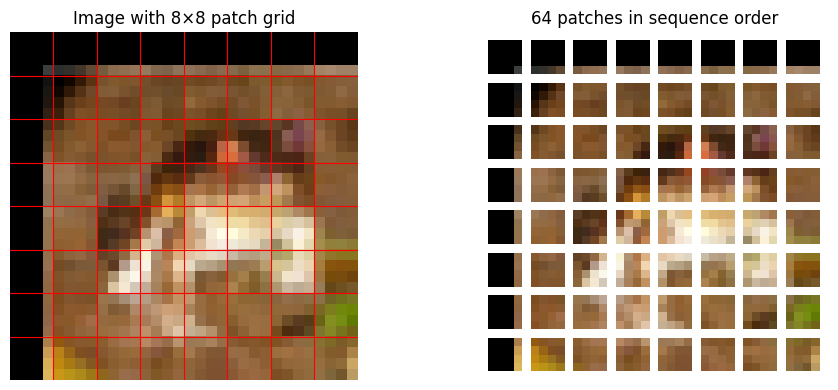

In [38]:
# --- Visualization helper (complete) ---

def visualize_patches(image_tensor, patch_size=4):
    """Show an image decomposed into its patch grid."""
    # Unnormalize for display
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image_tensor.cpu() * std + mean
    img = img.clamp(0, 1)

    C, H, W = img.shape
    n_h, n_w = H // patch_size, W // patch_size

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Left: original image with grid overlay
    axes[0].imshow(img.permute(1, 2, 0).numpy())
    for i in range(1, n_h):
        axes[0].axhline(y=i * patch_size - 0.5, color='red', linewidth=0.8)
    for j in range(1, n_w):
        axes[0].axvline(x=j * patch_size - 0.5, color='red', linewidth=0.8)
    axes[0].set_title(f'Image with {n_h}×{n_w} patch grid')
    axes[0].axis('off')

    # Right: patches laid out in sequence order
    patches = img.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    # patches shape: (C, n_h, n_w, patch_size, patch_size)
    patches = patches.permute(1, 2, 0, 3, 4).contiguous()
    # patches shape: (n_h, n_w, C, patch_size, patch_size)
    patches = patches.view(n_h * n_w, C, patch_size, patch_size)

    grid = torchvision.utils.make_grid(patches, nrow=n_w, padding=1, pad_value=1.0)
    axes[1].imshow(grid.permute(1, 2, 0).numpy())
    axes[1].set_title(f'{n_h * n_w} patches in sequence order')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Grab one sample and visualize
sample_img, sample_label = trainset[0]
print(f"Label: {CIFAR_CLASSES[sample_label]}")
print(f"Image shape: {sample_img.shape}  →  C, H, W")
print(f"Each patch flattened: {config.in_channels}×{config.patch_size}×{config.patch_size} = {config.patch_dim} values")
visualize_patches(sample_img, config.patch_size)

---
## Section 4 — Task: Patch Embedding Layer

### What this component does

The `PatchEmbedding` layer converts a batch of images into a sequence of patch embeddings suitable for the Transformer. It performs three operations:

1. **Extract and embed patches.** Chop the image into non-overlapping patches and project each flattened patch from dimension `patch_dim` to `d_model` using a linear layer.

2. **Prepend the CLS token.** Add a learned `[CLS]` embedding at position 0 of the sequence. After the Transformer processes the full sequence, the output at position 0 (the CLS token's final representation) is used for classification.

3. **Add positional embeddings.** Add a learned positional embedding to every position (including CLS). Without this, the Transformer has no notion of spatial arrangement — the patch at top-left would be indistinguishable from the patch at bottom-right.

### Input / Output specs

**Input:**
- `x`: shape `(B, C, H, W)` — a batch of images. For CIFAR-10: `(B, 3, 32, 32)`.

**Output:**
- `out`: shape `(B, N+1, D)` — the embedded patch sequence, where `N` = `num_patches` (64 for our config) and the `+1` is the CLS token. `D` = `d_model` (256).

### Implementation pseudocode

```
1. Extract patches using a Conv2d with kernel_size=patch_size and stride=patch_size.
   This is mathematically equivalent to slicing the image into patches and
   applying a linear layer to each, but faster.
   - Conv2d(in_channels=3, out_channels=d_model, kernel_size=patch_size, stride=patch_size)
   - Input:  (B, C, H, W) = (B, 3, 32, 32)
   - Output: (B, d_model, H/patch_size, W/patch_size) = (B, 256, 8, 8)

2. Reshape the conv output from (B, D, h, w) to (B, N, D) where N = h*w.
   - Flatten the spatial dims (last two) → (B, D, N), then transpose to (B, N, D).

3. Prepend CLS token:
   - self.cls_token is a learnable Parameter of shape (1, 1, D).
   - Expand it to (B, 1, D) using .expand(B, -1, -1).
   - Concatenate with patch embeddings along dim=1 → (B, N+1, D).

4. Add positional embeddings:
   - self.pos_embed is a learnable Parameter of shape (1, N+1, D).
   - Simply add: output = patches + self.pos_embed (broadcasts over batch).

5. Apply dropout.
```

> **Why Conv2d instead of manual slicing + Linear?** They produce identical results mathematically — a conv with kernel_size=stride=P extracts non-overlapping P×P patches and projects them, which is exactly flatten-then-linear. But Conv2d is a single fused CUDA kernel: one memory pass vs. two. The original ViT paper uses linear projection; most implementations use Conv2d for speed. You could do either.

> **Why a CLS token instead of, say, global average pooling?** The original ViT paper followed BERT's convention: a special token whose representation aggregates global information via attention. They found CLS and global average pooling performed similarly, but CLS is standard in the literature. CLIP's image encoder also uses a CLS token. We'll revisit this choice in an ablation.

In [39]:
class PatchEmbedding(nn.Module):
    """Convert images to a sequence of patch embeddings with CLS token and position embeddings.

    Args:
        config: ViTConfig with image_size, patch_size, in_channels, d_model, num_patches, dropout.

    Forward:
        x: (B, C, H, W) → out: (B, N+1, D)
    """
    def __init__(self, config):
        super().__init__()
        # YOUR CODE HERE
        self.patch_size = config.patch_size
        self.d_model = config.d_model
        self.num_patches = config.num_patches

        self.patch_embd_layer = nn.Conv2d(in_channels=3,out_channels=self.d_model,kernel_size=self.patch_size,stride=self.patch_size)
        self.cls = nn.Parameter(torch.zeros((1,1,self.d_model)))
        self.dropout = nn.Dropout(config.dropout)
        self.pos_embd = nn.Parameter(torch.zeros((1,self.num_patches+1,self.d_model)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, C, H, W) — batch of images

        Returns:
            (B, num_patches + 1, d_model) — patch embeddings with CLS token
        """
        # YOUR CODE HERE
        B= x.shape[0]
        patch_embd = self.patch_embd_layer(x)
        patch_embd = patch_embd.flatten(2).transpose(1,2)
        cls = self.cls.expand(B,-1,-1)
        patch_embd = torch.cat([cls,patch_embd],dim=1)
        out = patch_embd + self.pos_embd
        out = self.dropout(out)
        return out

### Sanity check — Patch Embedding

In [40]:
# --- Sanity check: PatchEmbedding ---
_pe = PatchEmbedding(config).to(DEVICE)
_x = torch.randn(2, 3, 32, 32).to(DEVICE)
_out = _pe(_x)

assert _out.shape == (2, config.num_patches + 1, config.d_model), \
    f"Expected (2, {config.num_patches + 1}, {config.d_model}), got {_out.shape}"

# Verify CLS token is at position 0 and is the same learned embedding for both batch items
# (before attention mixes things, the CLS should differ only by dropout)
_pe.eval()
with torch.no_grad():
    _out_eval = _pe(_x)
# CLS position exists and has correct dim
assert _out_eval[:, 0, :].shape == (2, config.d_model)
print(f"✓ PatchEmbedding output shape: {_out.shape}")
print(f"  Sequence length = {config.num_patches} patches + 1 CLS = {config.num_patches + 1}")

# Count parameters
_n_params = sum(p.numel() for p in _pe.parameters())
print(f"  Parameters: {_n_params:,}")
del _pe, _x, _out, _out_eval

✓ PatchEmbedding output shape: torch.Size([2, 65, 256])
  Sequence length = 64 patches + 1 CLS = 65
  Parameters: 29,440


---
## Section 5 — Task: Bidirectional Multi-Head Self-Attention

### What this component does

This is the attention mechanism you already know from GPT — with one critical difference: **no causal mask**.

Recall from your GPT project:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In GPT, you applied a mask before the softmax to prevent each position from attending to future positions. Here, **we skip that mask entirely**. Every patch can attend to every other patch, including itself. This is what makes it "bidirectional."

### Why bidirectional?

In language generation, the model predicts the next token, so it *must not* see future tokens during training. In image classification, all patches are available simultaneously — there is no sequential dependency. Masking would throw away useful information for no reason.

This is the same reason BERT uses bidirectional attention for understanding tasks while GPT uses causal attention for generation tasks.

### Input / Output specs

**Input:**
- `x`: shape `(B, N, D)` — the patch sequence (including CLS), where `N = num_patches + 1`.

**Output:**
- `out`: shape `(B, N, D)` — same shape, after multi-head attention.

### Implementation pseudocode

```
1. Project input to Q, K, V using three linear layers (or one combined linear → split).
   x: (B, N, D) → Q, K, V each: (B, N, D)

2. Reshape for multi-head: split D into (n_heads, d_k) where d_k = D / n_heads.
   Q: (B, N, D) → (B, N, n_heads, d_k) → transpose to (B, n_heads, N, d_k)
   Same for K and V.

3. Compute attention scores:
   scores = Q @ K^T / sqrt(d_k)
   scores shape: (B, n_heads, N, N)

   *** NO CAUSAL MASK — this is the key difference from GPT ***

4. attn_weights = softmax(scores, dim=-1)
5. Apply dropout to attn_weights.
6. attn_output = attn_weights @ V  →  (B, n_heads, N, d_k)

7. Reshape back: (B, n_heads, N, d_k) → (B, N, n_heads, d_k) → (B, N, D)
   Use .transpose(1,2).contiguous().view(B, N, D)

8. Final linear projection: (B, N, D) → (B, N, D)
```

> **Why this is the same component that appears in CLIP, BERT, and every encoder-only model:** The attention math is identical everywhere. The *only* difference between "encoder attention" and "decoder attention" is whether you apply a causal mask. One line of code (or its absence) determines the entire behavioral difference.

In [41]:
class MultiHeadSelfAttention(nn.Module):
    """Bidirectional multi-head self-attention (no causal mask).

    Args:
        config: ViTConfig with d_model, n_heads, dropout.

    Forward:
        x: (B, N, D) → out: (B, N, D)
    """
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.n_heads == 0
        # YOUR CODE HERE
        self.d_k = config.d_model//config.n_heads
        self.n_heads = config.n_heads
        self.qkv_proj = nn.Linear(config.d_model,3*config.d_model)
        self.proj = nn.Linear(config.d_model,config.d_model)
        self.dropout = nn.Dropout(config.dropout)


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, N, D) — sequence of patch embeddings

        Returns:
            (B, N, D) — after multi-head self-attention
        """
        # YOUR CODE HERE
        B,N,D = x.shape
        qkv = self.qkv_proj(x)
        q,k,v = qkv.split(D,dim=-1)
        q = q.view(B,N,self.n_heads,self.d_k).transpose(1,2)
        k = k.view(B,N,self.n_heads,self.d_k).transpose(1,2)
        v = v.view(B,N,self.n_heads,self.d_k).transpose(1,2)
        scores = q @ k.transpose(-2,-1) / math.sqrt(self.d_k)
        attn_weights = F.softmax(scores,dim=-1)
        self._attn_weights = attn_weights #store for visualization
        output = attn_weights @ v
        output = self.dropout(output)
        output = output.transpose(1,2).contiguous().view(B,N,D)
        return self.proj(output)


### Sanity check — Bidirectional Attention

Two critical checks:
1. **Output shape** is correct.
2. **Bidirectional behavior verified:** Perturb one token → *all* positions in the output change. (In your GPT, perturbing token $t$ only affected outputs at positions $\geq t$. Here, because there's no mask, the change propagates everywhere.)

In [42]:
# --- Sanity check: MultiHeadSelfAttention ---
_attn = MultiHeadSelfAttention(config).to(DEVICE)
_attn.eval()

_x = torch.randn(1, config.num_patches + 1, config.d_model).to(DEVICE)

with torch.no_grad():
    _out1 = _attn(_x)

# Shape check
assert _out1.shape == _x.shape, f"Expected {_x.shape}, got {_out1.shape}"
print(f"✓ Attention output shape: {_out1.shape}")

# Bidirectional check: perturb token at position 32 (middle of sequence)
_x_perturbed = _x.clone()
_x_perturbed[0, 32, :] += 10.0  # large perturbation

with torch.no_grad():
    _out2 = _attn(_x_perturbed)

# In bidirectional attention, ALL positions should be affected
_diffs = (_out1 - _out2).abs().sum(dim=-1)  # (1, N)
_changed = (_diffs > 1e-5).sum().item()
_total = _out1.shape[1]
assert _changed == _total, \
    f"Bidirectional check failed: only {_changed}/{_total} positions changed. Is a causal mask applied?"
print(f"✓ Bidirectional: perturbing 1 token changed all {_total}/{_total} positions")

del _attn, _x, _x_perturbed, _out1, _out2, _diffs, _changed, _total

✓ Attention output shape: torch.Size([1, 65, 256])
✓ Bidirectional: perturbing 1 token changed all 65/65 positions


---
## Section 6 — Task: Transformer Block

### What this component does

The Transformer block is the same structure you built in GPT:

```
x → LayerNorm → MultiHeadSelfAttention → + residual → LayerNorm → FFN → + residual → out
```

This is the **pre-norm** convention (LayerNorm *before* each sub-layer), which is what GPT-2, ViT, Llama, and most modern architectures use. The original Transformer paper used post-norm (LayerNorm *after*), but pre-norm trains more stably.

### The FFN sub-layer

A two-layer MLP with GELU activation:
```
FFN(x) = Linear(GELU(Linear(x)))
         D → d_ff → D
```

### Input / Output specs

**Input:** `x: (B, N, D)`
**Output:** `out: (B, N, D)`

### Implementation pseudocode

```
1. residual = x
2. x = LayerNorm(x)
3. x = MultiHeadSelfAttention(x)
4. x = Dropout(x)
5. x = x + residual

6. residual = x
7. x = LayerNorm(x)
8. x = FFN(x)        # Linear(D, d_ff) → GELU → Dropout → Linear(d_ff, D) → Dropout
9. x = x + residual
```

> **Why GELU instead of ReLU?** GELU (Gaussian Error Linear Unit) is a smooth approximation to ReLU that has become standard in Transformers since GPT-2. Unlike ReLU, it doesn't have a hard zero for negative inputs — it allows a small gradient to flow for slightly negative values. Llama uses SwiGLU (a gated variant) for even better performance; GELU is the baseline choice.

In [43]:
class TransformerBlock(nn.Module):
    """Pre-norm Transformer block: LN → MHSA → residual → LN → FFN → residual.

    Args:
        config: ViTConfig with d_model, n_heads, d_ff, dropout.

    Forward:
        x: (B, N, D) → out: (B, N, D)
    """
    def __init__(self, config):
        super().__init__()
        # YOUR CODE HERE
        self.attn_block = MultiHeadSelfAttention(config)
        self.dropout = nn.Dropout(config.dropout)
        d_ff = config.d_model * 4
        self.ln_1 = nn.LayerNorm(config.d_model)
        self.ln_2 = nn.LayerNorm(config.d_model)
        self.ffn = nn.Sequential(
            nn.Linear(config.d_model,d_ff),
            nn.GELU(),
            nn.Dropout(config.dropout),
            nn.Linear(d_ff,config.d_model),
            nn.Dropout(config.dropout)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, N, D)

        Returns:
            (B, N, D)
        """
        # YOUR CODE HERE
        residual = x
        x = self.ln_1(x)
        x = self.attn_block(x)
        x = x + residual

        residual = x
        x = self.ln_2(x)
        x = self.ffn(x)
        x = x + residual
        return x

### Sanity check — Transformer Block

We check two things:
1. Output shape matches input shape.
2. **Residual connection works:** If attention and FFN weights are zero-initialized, the block should be approximately an identity function (output ≈ input). We won't literally zero-init here, but we verify the residual path exists by checking the output is *not* zero when the input is nonzero.

In [44]:
# --- Sanity check: TransformerBlock ---
_block = TransformerBlock(config).to(DEVICE)
_x = torch.randn(2, config.num_patches + 1, config.d_model).to(DEVICE)

with torch.no_grad():
    _out = _block(_x)

assert _out.shape == _x.shape, f"Expected {_x.shape}, got {_out.shape}"
print(f"✓ TransformerBlock output shape: {_out.shape}")

# Verify output is not all zeros (residual connection exists)
assert _out.abs().sum() > 0, "Output is all zeros — residual connection may be missing"
print("✓ Output is non-zero (residual path active)")

# Verify gradients flow
_out = _block(_x)
_out.sum().backward()
_has_grad = all(p.grad is not None for p in _block.parameters() if p.requires_grad)
assert _has_grad, "Some parameters have no gradient"
print("✓ Gradients flow through all parameters")

del _block, _x, _out

✓ TransformerBlock output shape: torch.Size([2, 65, 256])
✓ Output is non-zero (residual path active)
✓ Gradients flow through all parameters


---
## Section 7 — Task: Complete Vision Transformer

### What this component does

The full ViT model stacks all components together:

```
Image → PatchEmbedding → [TransformerBlock × n_layers] → LayerNorm → CLS token → Classification head
```

### Architecture overview

1. `PatchEmbedding` converts the image to `(B, N+1, D)`.
2. `n_layers` `TransformerBlock`s process the sequence. Each block lets every patch attend to every other patch, progressively building richer representations.
3. A final `LayerNorm` is applied to the full sequence.
4. **Extract the CLS token** — take only position 0 from the sequence: `(B, D)`.
5. A `Linear(D, num_classes)` classification head maps the CLS representation to class logits.

### Input / Output specs

**Input:** `x: (B, C, H, W)` — batch of images
**Output:** `logits: (B, num_classes)` — raw class scores (no softmax — `nn.CrossEntropyLoss` handles that)

### Implementation pseudocode

```
1. x = PatchEmbedding(x)                  # (B, C, H, W) → (B, N+1, D)
2. for block in transformer_blocks:
       x = block(x)                        # (B, N+1, D) → (B, N+1, D)
3. x = LayerNorm(x)                        # (B, N+1, D)
4. cls_output = x[:, 0]                    # (B, D)  — CLS token only
5. logits = classification_head(cls_output) # (B, num_classes)
```

> **Why extract only the CLS token for classification?** During attention, the CLS token attends to *all* patches. Over multiple layers, it accumulates a global representation of the entire image. The patch tokens also have useful representations (and are used in segmentation tasks like SegViT), but for classification, the CLS token is standard.

In [61]:
class ViT(nn.Module):
    """Vision Transformer for image classification.

    Args:
        config: ViTConfig with all model and task hyperparameters.

    Forward:
        x: (B, C, H, W) → logits: (B, num_classes)
    """
    def __init__(self, config):
        super().__init__()
        # YOUR CODE HERE
        self.patch_embd = PatchEmbedding(config)
        self.transformer_blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
        self.ln = nn.LayerNorm(config.d_model)
        self.classifier = nn.Linear(config.d_model,config.num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: (B, C, H, W) — batch of images

        Returns:
            (B, num_classes) — class logits
        """
        # YOUR CODE HERE
        x = self.patch_embd(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.ln(x)
        cls = x[:,0,:]
        logits = self.classifier(cls)
        return logits


### Sanity check — Full ViT

**Critical check:** At random initialization, the model should produce roughly uniform predictions over 10 classes. This means the cross-entropy loss should be approximately $\ln(10) \approx 2.302$. If you see a loss much higher or lower, something is wrong.

In [62]:
# --- Sanity check: Full ViT ---
_model = ViT(config).to(DEVICE)
_x = torch.randn(4, 3, 32, 32).to(DEVICE)
_labels = torch.randint(0, 10, (4,)).to(DEVICE)

with torch.no_grad():
    _logits = _model(_x)

assert _logits.shape == (4, config.num_classes), f"Expected (4, {config.num_classes}), got {_logits.shape}"
print(f"✓ ViT output shape: {_logits.shape}")

# Loss at random init should be ≈ ln(10) ≈ 2.302
_loss = F.cross_entropy(_logits, _labels)
print(f"  Loss at random init: {_loss.item():.3f}  (expected ≈ {math.log(config.num_classes):.3f})")
assert 1.5 < _loss.item() < 4.0, f"Loss {_loss.item():.3f} is suspiciously far from ln(10)"
print("✓ Loss is in expected range for random init")

# Parameter count
_total_params = sum(p.numel() for p in _model.parameters())
_trainable = sum(p.numel() for p in _model.parameters() if p.requires_grad)
print(f"  Total parameters: {_total_params:,}")
print(f"  Trainable parameters: {_trainable:,}")

del _model, _x, _labels, _logits, _loss

✓ ViT output shape: torch.Size([4, 10])
  Loss at random init: 2.470  (expected ≈ 2.303)
✓ Loss is in expected range for random init
  Total parameters: 4,771,082
  Trainable parameters: 4,771,082


---
## Section 8 — Training Loop

The training loop is provided complete — this is scaffolding, not core ML logic. It uses:
- **AdamW** optimizer with weight decay (standard for Transformers).
- **Cosine annealing** learning rate schedule with linear warmup — the same schedule used in the ViT paper and most modern Transformer training.
- Training/test accuracy and loss tracking per epoch.

> **Why cosine LR schedule with warmup?** Transformers are sensitive to learning rate early in training. The warmup phase (5 epochs here) ramps the LR from 0 to `config.lr`, preventing large gradient updates when the model is still randomly initialized. After warmup, cosine annealing smoothly decays the LR, which generally outperforms step decay for attention-based models.

In [63]:
def get_cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    """Cosine annealing with linear warmup. Returns a LambdaLR scheduler."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def evaluate(model, dataloader, device):
    """Compute loss and accuracy on a dataset."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += F.cross_entropy(logits, labels, reduction='sum').item()
            correct += (logits.argmax(dim=-1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total


def train_vit(model, trainloader, testloader, config, device):
    """Full training loop with warmup + cosine schedule. Returns metrics dict."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr,
                                   weight_decay=config.weight_decay)
    scheduler = get_cosine_schedule_with_warmup(optimizer,
                                                 warmup_epochs=5,
                                                 total_epochs=config.epochs)

    metrics = {
        'train_losses': [], 'train_accs': [],
        'test_losses': [], 'test_accs': [],
        'epoch_times': [], 'lrs': []
    }

    for epoch in range(config.epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            # Gradient clipping — standard for Transformers
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=-1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        epoch_time = time.time() - t0

        train_loss = running_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, testloader, device)

        current_lr = scheduler.get_last_lr()[0]
        metrics['train_losses'].append(train_loss)
        metrics['train_accs'].append(train_acc)
        metrics['test_losses'].append(test_loss)
        metrics['test_accs'].append(test_acc)
        metrics['epoch_times'].append(epoch_time)
        metrics['lrs'].append(current_lr)

        print(f"Epoch {epoch+1:2d}/{config.epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} | "
              f"Test Loss: {test_loss:.4f} Acc: {test_acc:.3f} | "
              f"LR: {current_lr:.6f} | Time: {epoch_time:.1f}s")

    return metrics

In [64]:
# --- Train the ViT ---

METRICS_PATH = 'metrics/vit_baseline_metrics.pt'
MODEL_PATH   = 'models/vit_baseline.pt'

model = ViT(config).to(DEVICE)

if os.path.exists(METRICS_PATH) and os.path.exists(MODEL_PATH):
    baseline_metrics = torch.load(METRICS_PATH)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print("Loaded cached metrics and model.")
else:
    baseline_metrics = train_vit(model, trainloader, testloader, config, DEVICE)

    os.makedirs('metrics', exist_ok=True)
    os.makedirs('models',  exist_ok=True)
    torch.save(baseline_metrics, METRICS_PATH)
    torch.save(model.state_dict(), MODEL_PATH)
    print("Training complete. Metrics and model saved.")
test_accs = baseline_metrics['test_accs']
best_epoch = max(range(len(test_accs)), key=lambda i: test_accs[i])
print(f"Best test accuracy: {test_accs[best_epoch]:.4f} (epoch {best_epoch + 1})")

Loaded cached metrics and model.
Best test accuracy: 0.8115 (epoch 28)


---
## Section 9 — Training Visualization

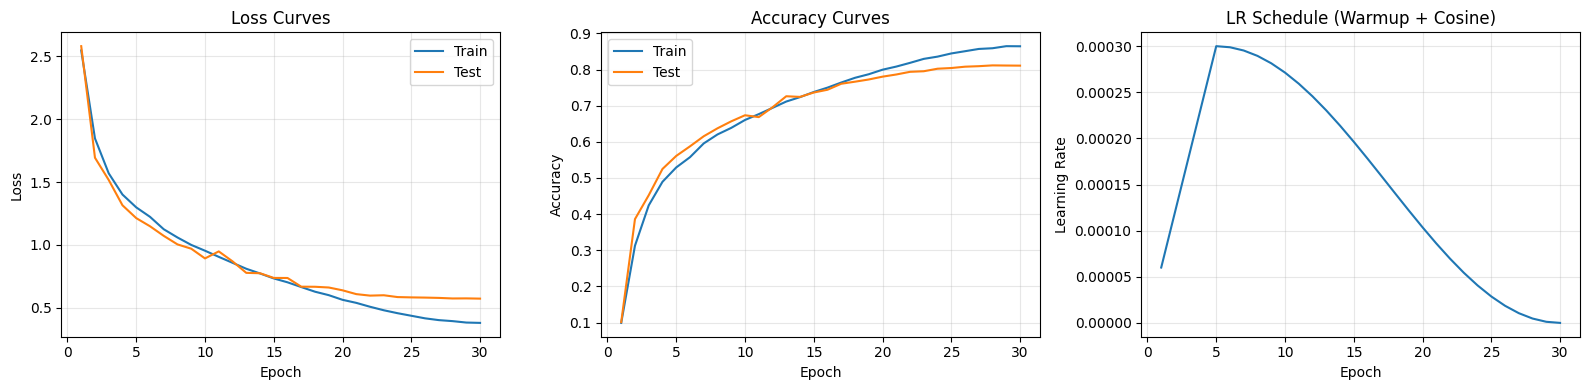

Best test accuracy: 0.811 (epoch 28)


In [65]:
# --- Plot training curves (complete) ---

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

epochs = range(1, len(baseline_metrics['train_losses']) + 1)

# Loss
axes[0].plot(epochs, baseline_metrics['train_losses'], label='Train')
axes[0].plot(epochs, baseline_metrics['test_losses'], label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, baseline_metrics['train_accs'], label='Train')
axes[1].plot(epochs, baseline_metrics['test_accs'], label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule
axes[2].plot(epochs, baseline_metrics['lrs'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule (Warmup + Cosine)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best test accuracy: {max(baseline_metrics['test_accs']):.3f} "
      f"(epoch {baseline_metrics['test_accs'].index(max(baseline_metrics['test_accs'])) + 1})")

---
## Section 10 — Task: Visualize Attention Maps

### What we're exploring

One of the most important properties of ViT is that its attention maps are *interpretable*. Each head in each layer learns to attend to different parts of the image. Early layers tend to have diffuse, local attention; later layers often show more semantic, long-range attention patterns.

Your task is to implement a forward hook that captures the attention weights from each layer's attention module, then visualize them as heatmaps overlaid on the original image.

### What to implement

Write a function `get_attention_maps` that:

1. Registers forward hooks on the attention modules to capture the attention weight matrix (the output of softmax, *before* multiplying by V).
2. Runs a single forward pass on one image.
3. Returns a list of attention weight tensors, one per layer.

**This requires modifying your `MultiHeadSelfAttention.forward` to store `attn_weights` as `self._attn_weights` after the softmax step (a single extra line).** Then the hook can read `module._attn_weights`.

### Specs

**Input:** A single image tensor `(1, C, H, W)` and the trained model.
**Output:** List of `n_layers` tensors, each of shape `(n_heads, N+1, N+1)` — the attention weight matrix for each layer.

The visualization helper is provided — you just need to implement the extraction.

In [66]:
class AttentionCapture:
    def __init__(self):
        self.attn_maps = []
    
    def hook_fn(self, module,inputs,output):
        self.attn_maps.append(module._attn_weights[0].detach().cpu())

def get_attention_maps(model, image: torch.Tensor, device) -> list:
    """Extract attention maps from all layers for a single image.

    Prerequisites:
        Each MultiHeadSelfAttention module must store its attention weights
        (post-softmax, pre-dropout) as self._attn_weights during forward.
        Shape: (B, n_heads, N+1, N+1)

    Args:
        model: trained ViT model
        image: (1, C, H, W) — single image batch
        device: torch device

    Returns:
        List of n_layers tensors, each (n_heads, N+1, N+1)
    """
    # YOUR CODE HERE
    capture = AttentionCapture()
    image = image.to(device)
    
    hooks = []
    for block in model.transformer_blocks:
        h = block.attn_block.register_forward_hook(capture.hook_fn)
        hooks.append(h)
    
    model.eval()
    with torch.no_grad():
        model(image)
    
    for h in hooks:
        h.remove()
    
    return capture.attn_maps

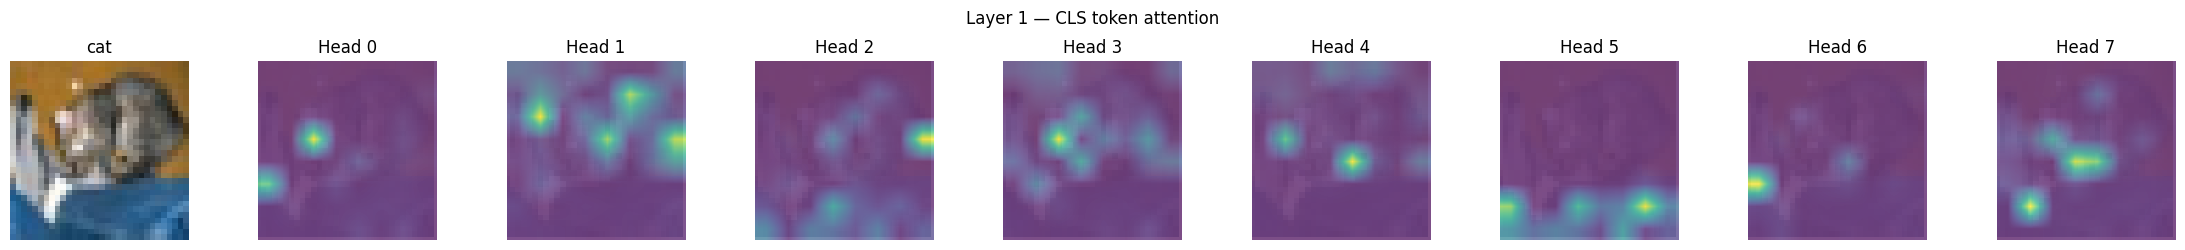

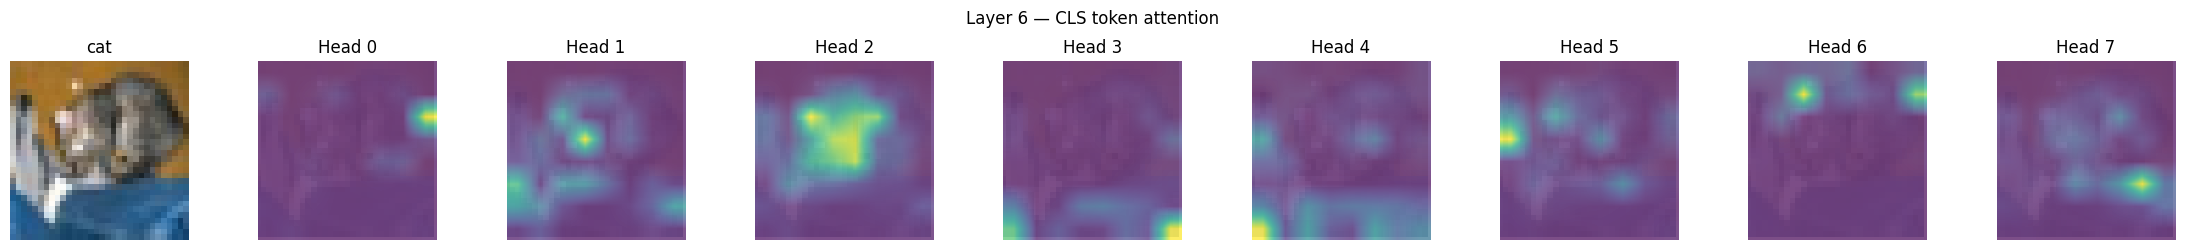

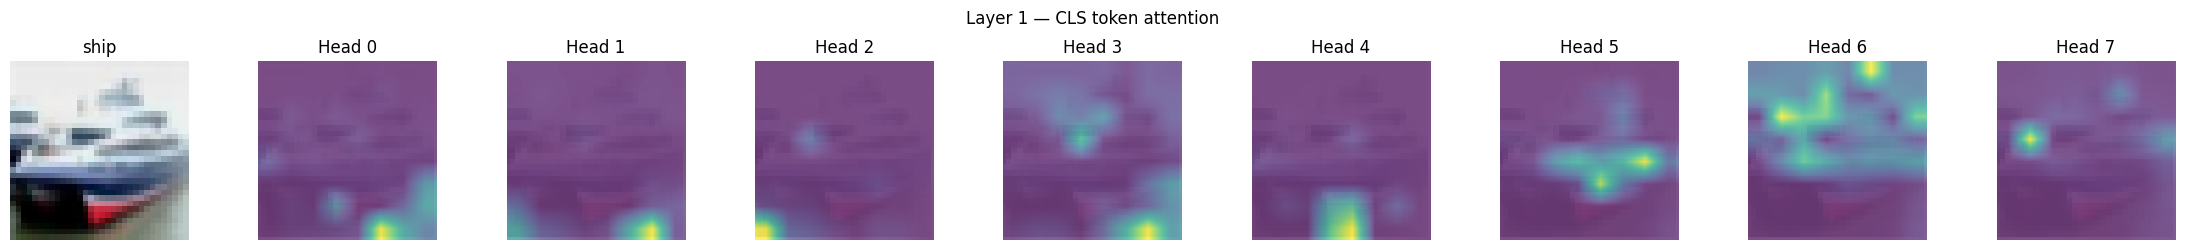

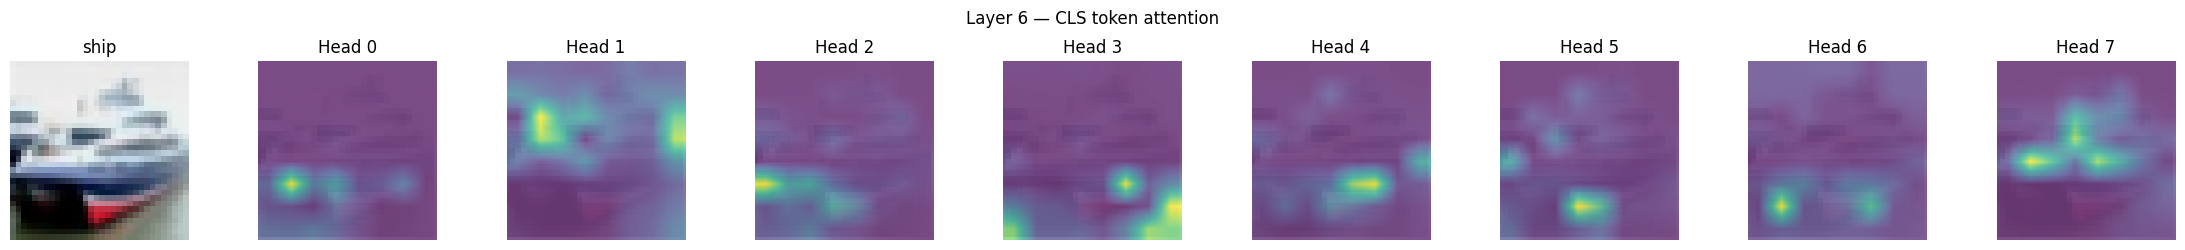

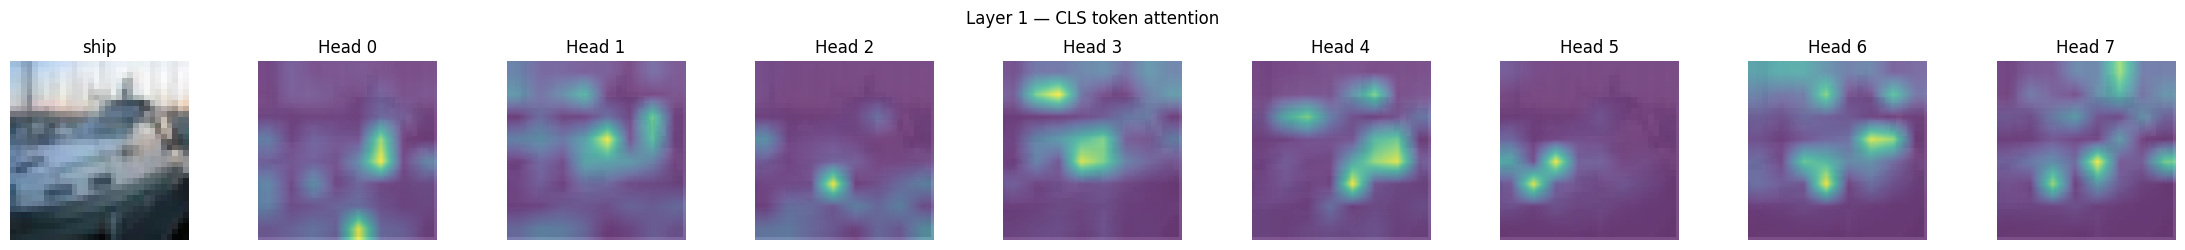

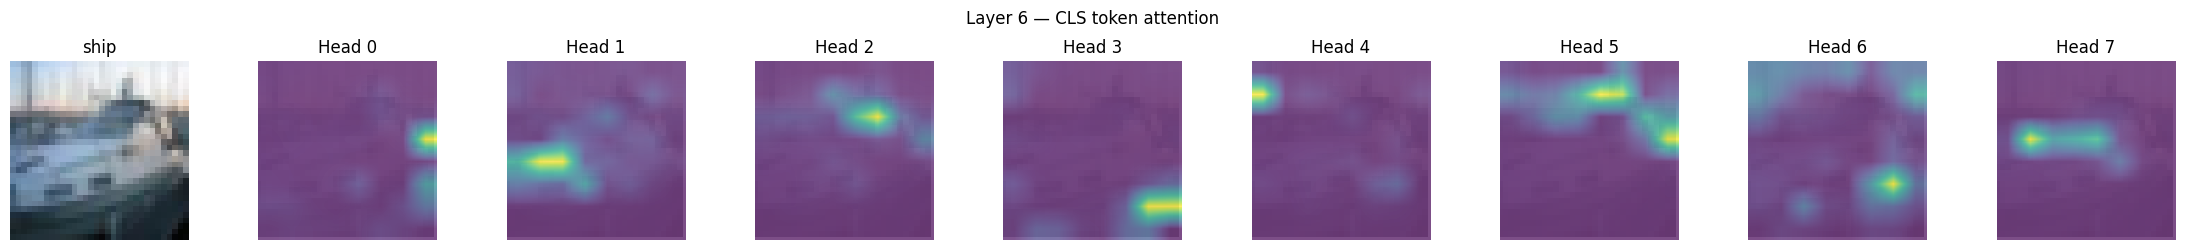

In [67]:
# --- Visualization helper (complete) ---

def visualize_attention(model, image_tensor, label, config, device):
    """Visualize attention from the CLS token to all patches."""
    attn_maps = get_attention_maps(model, image_tensor.unsqueeze(0), device)

    # Unnormalize image for display
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = image_tensor.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()

    n_h = config.image_size // config.patch_size

    # Show CLS→patches attention for all heads in first and last layer
    for layer_idx in [0, config.n_layers - 1]:
        attn = attn_maps[layer_idx]  # (n_heads, N+1, N+1)
        cls_attn = attn[:, 0, 1:]    # (n_heads, N) — CLS attending to patches

        fig, axes = plt.subplots(1, config.n_heads + 1, figsize=(2.5 * (config.n_heads + 1), 2.5))
        axes[0].imshow(img)
        axes[0].set_title(f'{CIFAR_CLASSES[label]}')
        axes[0].axis('off')

        for head in range(config.n_heads):
            attn_grid = cls_attn[head].view(n_h, n_h).cpu().numpy()
            axes[head + 1].imshow(img, alpha=0.3)
            axes[head + 1].imshow(attn_grid, cmap='viridis', alpha=0.7,
                                   interpolation='bilinear',
                                   extent=[0, config.image_size, config.image_size, 0])
            axes[head + 1].set_title(f'Head {head}')
            axes[head + 1].axis('off')

        fig.suptitle(f'Layer {layer_idx + 1} — CLS token attention', fontsize=12)
        plt.tight_layout()
        plt.show()


# Run on a few test images
model.eval()
for i in range(3):
    img, label = testset[i]
    visualize_attention(model, img, label, config, DEVICE)

---
## Section 11 — Ablation: CLS Token vs Global Average Pooling

### Hypothesis

_Before running this experiment, write your prediction:_

**Hypothesis:** When we replace the CLS token with global average pooling (averaging all patch token representations after the last Transformer layer), I predict the test accuracy will be ___lower____ (higher / lower / similar) because _______.

### Task: Implement GAP variant

Create a `ViT_GAP` model that is identical to your ViT but:
- Does **not** prepend a CLS token in `PatchEmbedding`.
- After the Transformer blocks + final LayerNorm, applies **global average pooling** over the sequence dimension: `x.mean(dim=1)` → `(B, D)`.
- Feeds that averaged representation to the classification head.

This requires modifying two things:
1. A new `PatchEmbeddingNoCLS` that skips the CLS token (sequence length = N, not N+1). Positional embeddings should have shape `(1, N, D)`.
2. A new `ViT_GAP` that uses `PatchEmbeddingNoCLS` and `x.mean(dim=1)` instead of `x[:, 0]`.

In [68]:
class PatchEmbeddingNoCLS(nn.Module):
    """Patch embedding without CLS token, for the GAP variant.

    Forward:
        x: (B, C, H, W) → out: (B, N, D)   [N = num_patches, no +1]
    """
    def __init__(self, config):
        super().__init__()
        # YOUR CODE HERE
        self.patch_size = config.patch_size
        self.num_patches = config.num_patches
        self.d_model = config.d_model
        self.patch_embd_layer = nn.Conv2d(in_channels=3,out_channels=self.d_model,kernel_size=self.patch_size,stride=self.patch_size)
        self.dropout = nn.Dropout(config.dropout)
        self.pos_embd = nn.Parameter(torch.zeros((1,self.num_patches,self.d_model)))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE
        patch_embd = self.patch_embd_layer(x)
        patch_embd = patch_embd.flatten(2).transpose(1, 2)
        output = patch_embd + self.pos_embd
        output = self.dropout(output)
        return output

class ViT_GAP(nn.Module):
    """ViT with Global Average Pooling instead of CLS token.

    Forward:
        x: (B, C, H, W) → logits: (B, num_classes)
    """
    def __init__(self, config):
        super().__init__()
        # YOUR CODE HERE
        self.patch_embd = PatchEmbeddingNoCLS(config)
        self.transformer_blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layers)])
        self.ln = nn.LayerNorm(config.d_model)
        self.classifier = nn.Linear(config.d_model,config.num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # YOUR CODE HERE
        x = self.patch_embd(x)
        for block in self.transformer_blocks:
            x = block(x)
        x = self.ln(x)
        x = x.mean(dim=1)
        logits = self.classifier(x)
        return logits

In [69]:
# --- Sanity check: ViT_GAP ---
_model_gap = ViT_GAP(config).to(DEVICE)
_x = torch.randn(2, 3, 32, 32).to(DEVICE)
with torch.no_grad():
    _logits = _model_gap(_x)
assert _logits.shape == (2, config.num_classes), f"Expected (2, {config.num_classes}), got {_logits.shape}"
print(f"✓ ViT_GAP output shape: {_logits.shape}")
del _model_gap, _x, _logits

✓ ViT_GAP output shape: torch.Size([2, 10])


In [70]:
# --- Train GAP variant ---

GAP_METRICS_PATH = 'metrics/vit_gap_metrics.pt'
GAP_MODEL_PATH   = 'models/vit_gap.pt'

model_gap = ViT_GAP(config).to(DEVICE)

if os.path.exists(GAP_METRICS_PATH) and os.path.exists(GAP_MODEL_PATH):
    gap_metrics = torch.load(GAP_METRICS_PATH, weights_only=True)
    model_gap.load_state_dict(torch.load(GAP_MODEL_PATH, map_location=DEVICE, weights_only=True))
    print("Loaded cached GAP metrics and model.")
else:
    gap_metrics = train_vit(model_gap, trainloader, testloader, config, DEVICE)

    os.makedirs('metrics', exist_ok=True)
    os.makedirs('models',  exist_ok=True)
    torch.save(gap_metrics, GAP_METRICS_PATH)
    torch.save(model_gap.state_dict(), GAP_MODEL_PATH)
    print("GAP training complete. Metrics and model saved.")
test_accs = gap_metrics['test_accs']
best_epoch = max(range(len(test_accs)), key=lambda i: test_accs[i])
print(f"Best test accuracy: {test_accs[best_epoch]:.4f} (epoch {best_epoch + 1})")

Loaded cached GAP metrics and model.
Best test accuracy: 0.8166 (epoch 30)


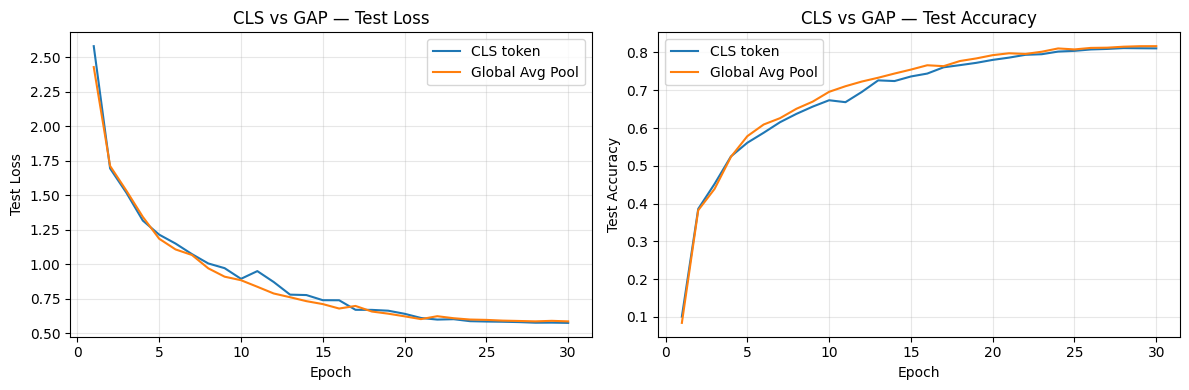

CLS best test acc: 0.811
GAP best test acc: 0.817


In [71]:
# --- Compare CLS vs GAP ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(baseline_metrics['test_accs']) + 1)

axes[0].plot(epochs, baseline_metrics['test_losses'], label='CLS token')
axes[0].plot(epochs, gap_metrics['test_losses'], label='Global Avg Pool')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Loss')
axes[0].set_title('CLS vs GAP — Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, baseline_metrics['test_accs'], label='CLS token')
axes[1].plot(epochs, gap_metrics['test_accs'], label='Global Avg Pool')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('CLS vs GAP — Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"CLS best test acc: {max(baseline_metrics['test_accs']):.3f}")
print(f"GAP best test acc: {max(gap_metrics['test_accs']):.3f}")

### Observation

> The model with CLS token achieved a best test accuracy of ___%, while the GAP model achieved ___%.

> This suggests that for small datasets like CIFAR-10, the pooling strategy (matters / doesn't matter much) because ___.

> In the original ViT paper, the authors found ___. CLIP's image encoder uses ___ (CLS / GAP) because ___.

---
## Section 12 — Ablation: With vs Without Positional Embeddings

### Hypothesis

**Hypothesis:** Removing positional embeddings will (increase / decrease) accuracy by approximately ___% because ___. Without positional information, the model (can / cannot) distinguish between ___ and ___.

In [72]:
# --- Train ViT without positional embeddings ---
# We create a variant that zeros out the positional embedding

NOPOS_METRICS_PATH = 'metrics/vit_nopos_metrics.pt'
NOPOS_MODEL_PATH   = 'models/vit_nopos.pt'

model_nopos = ViT(config).to(DEVICE)
# Zero out positional embeddings and freeze them
with torch.no_grad():
    model_nopos.patch_embd.pos_embd.zero_()
model_nopos.patch_embd.pos_embd.requires_grad = False

if os.path.exists(NOPOS_METRICS_PATH) and os.path.exists(NOPOS_MODEL_PATH):
    nopos_metrics = torch.load(NOPOS_METRICS_PATH, weights_only=True)
    model_nopos.load_state_dict(torch.load(NOPOS_MODEL_PATH, map_location=DEVICE, weights_only=True))
    print("Loaded cached no-pos metrics and model.")
else:
    nopos_metrics = train_vit(model_nopos, trainloader, testloader, config, DEVICE)

    os.makedirs('metrics', exist_ok=True)
    os.makedirs('models',  exist_ok=True)
    torch.save(nopos_metrics, NOPOS_METRICS_PATH)
    torch.save(model_nopos.state_dict(), NOPOS_MODEL_PATH)
    print("No-pos training complete. Metrics and model saved.")
test_accs = nopos_metrics['test_accs']
best_epoch = max(range(len(test_accs)), key=lambda i: test_accs[i])
print(f"Best test accuracy: {test_accs[best_epoch]:.4f} (epoch {best_epoch + 1})")

Loaded cached no-pos metrics and model.
Best test accuracy: 0.7429 (epoch 30)


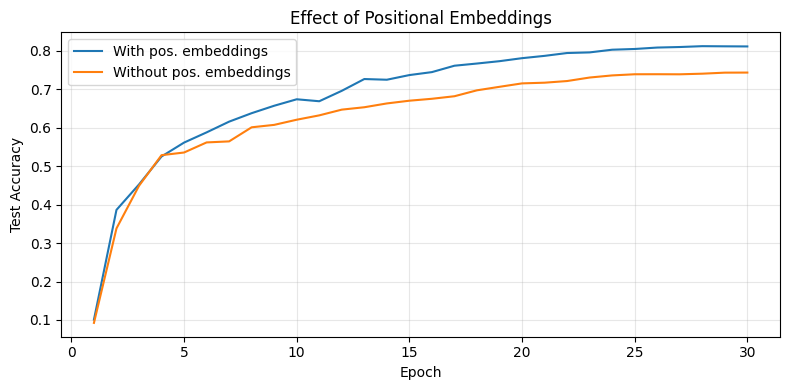

With pos emb best acc:    0.811
Without pos emb best acc: 0.743


In [73]:
# --- Compare with vs without positional embeddings ---

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

epochs = range(1, len(baseline_metrics['test_accs']) + 1)

ax.plot(epochs, baseline_metrics['test_accs'], label='With pos. embeddings')
ax.plot(epochs, nopos_metrics['test_accs'], label='Without pos. embeddings')
ax.set_xlabel('Epoch')
ax.set_ylabel('Test Accuracy')
ax.set_title('Effect of Positional Embeddings')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"With pos emb best acc:    {max(baseline_metrics['test_accs']):.3f}")
print(f"Without pos emb best acc: {max(nopos_metrics['test_accs']):.3f}")

### Observation

> Without positional embeddings, test accuracy dropped from ___% to ___%.

> This drop is (large / moderate / small) because for CIFAR-10's 32×32 images, spatial arrangement (matters a lot / matters somewhat / barely matters) — an airplane wing in the top-left is ___ different from one in the bottom-right for classification.

> This connects to a key insight about Transformers: unlike CNNs, self-attention is *permutation-equivariant* by default. Without positional embeddings, the output is invariant to the order of the input patches. Positional embeddings break this symmetry and inject ___.

---
## Section 13 — Visualize Learned Positional Embeddings

Let's look at what the positional embeddings actually learned. We compute the cosine similarity between each pair of position embeddings. If the model learned spatial structure, nearby patches should have more similar positional embeddings than distant patches.

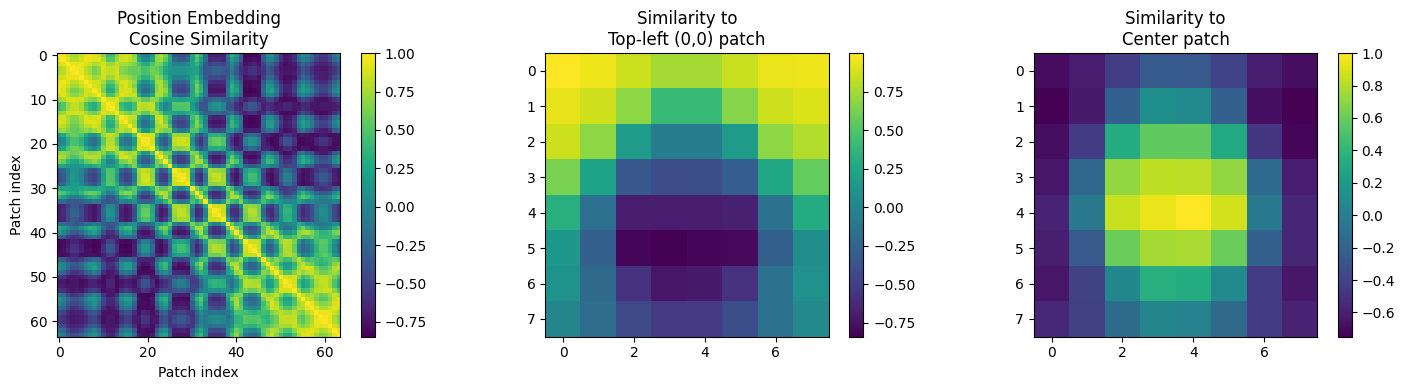

If the model learned spatial structure, you should see:
  - Diagonal dominance in the similarity matrix (nearby patches are similar)
  - Smooth gradients radiating from reference patches


In [74]:
# --- Visualize positional embeddings (complete) ---

with torch.no_grad():
    pos_emb = model.patch_embd.pos_embd[0].cpu()  # (N+1, D)

    # Drop CLS token (position 0) for spatial visualization
    patch_pos = pos_emb[1:]  # (N, D)

    # Cosine similarity matrix
    patch_pos_norm = F.normalize(patch_pos, dim=-1)
    cos_sim = patch_pos_norm @ patch_pos_norm.T  # (N, N)

n_h = config.image_size // config.patch_size

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Full similarity matrix
im = axes[0].imshow(cos_sim.numpy(), cmap='viridis')
axes[0].set_title('Position Embedding\nCosine Similarity')
axes[0].set_xlabel('Patch index')
axes[0].set_ylabel('Patch index')
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Similarity of corner patches to all others
for idx, (name, patch_idx) in enumerate([
    ('Top-left (0,0)', 0),
    ('Center', (n_h // 2) * n_h + n_h // 2)
]):
    sim_map = cos_sim[patch_idx].view(n_h, n_h).numpy()
    im = axes[idx + 1].imshow(sim_map, cmap='viridis', interpolation='nearest')
    axes[idx + 1].set_title(f'Similarity to\n{name} patch')
    plt.colorbar(im, ax=axes[idx + 1], fraction=0.046)

plt.tight_layout()
plt.show()

print("If the model learned spatial structure, you should see:")
print("  - Diagonal dominance in the similarity matrix (nearby patches are similar)")
print("  - Smooth gradients radiating from reference patches")

---
## Section 14 — Ablation: ViT vs CNN on CIFAR-10

### Hypothesis

**Hypothesis:** Compared to the ResNet-style CNN you built in Project 2, the ViT will achieve (higher / lower / similar) accuracy on CIFAR-10 because ___. ViTs are known to be data-hungry because they lack the ___ inductive bias that CNNs have.

### Context

The original ViT paper showed that ViTs underperform CNNs on small datasets (like CIFAR-10 and ImageNet-1k) but surpass them when trained on large datasets (ImageNet-21k, JFT-300M). This is because:

1. **CNNs** have **locality** (each filter sees only a small region) and **translation equivariance** (the same filter is applied everywhere). These inductive biases are helpful when data is scarce — they constrain the hypothesis space.

2. **ViTs** have **no spatial inductive bias** — every patch can attend to every other patch from layer 1. This flexibility is powerful but requires more data to learn spatial relationships that CNNs get for free.

Let's build a simple CNN to compare. This is provided complete so we can focus on the comparison.

In [75]:
# --- Simple CNN baseline (complete) ---

class SimpleCNN(nn.Module):
    """Small CNN baseline for comparison. ~same parameter count as our ViT."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


def train_cnn(model, trainloader, testloader, epochs, lr, device):
    """Train a CNN with the same schedule as ViT for fair comparison."""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = get_cosine_schedule_with_warmup(optimizer, warmup_epochs=5, total_epochs=epochs)

    metrics = {'train_losses': [], 'train_accs': [], 'test_losses': [], 'test_accs': [], 'epoch_times': []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = F.cross_entropy(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            correct += (logits.argmax(dim=-1) == labels).sum().item()
            total += labels.size(0)

        scheduler.step()
        epoch_time = time.time() - t0
        train_loss, train_acc = running_loss / total, correct / total
        test_loss, test_acc = evaluate(model, testloader, device)

        metrics['train_losses'].append(train_loss)
        metrics['train_accs'].append(train_acc)
        metrics['test_losses'].append(test_loss)
        metrics['test_accs'].append(test_acc)
        metrics['epoch_times'].append(epoch_time)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"Train: {train_loss:.4f} / {train_acc:.3f} | "
              f"Test: {test_loss:.4f} / {test_acc:.3f} | {epoch_time:.1f}s")

    return metrics

In [77]:
# --- Train CNN ---

CNN_METRICS_PATH = 'metrics/cnn_baseline_metrics.pt'
CNN_MODEL_PATH   = 'models/cnn_baseline.pt'

cnn_model = SimpleCNN(num_classes=10).to(DEVICE)

cnn_params = sum(p.numel() for p in cnn_model.parameters())
vit_params = sum(p.numel() for p in model.parameters())
print(f"CNN parameters: {cnn_params:,}")
print(f"ViT parameters: {vit_params:,}")

if os.path.exists(CNN_METRICS_PATH) and os.path.exists(CNN_MODEL_PATH):
    cnn_metrics = torch.load(CNN_METRICS_PATH, weights_only=True)
    cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=DEVICE, weights_only=True))
    print("Loaded cached CNN metrics and model.")
else:
    cnn_metrics = train_cnn(cnn_model, trainloader, testloader,
                             epochs=config.epochs, lr=config.lr, device=DEVICE)

    os.makedirs('metrics', exist_ok=True)
    os.makedirs('models',  exist_ok=True)
    torch.save(cnn_metrics, CNN_METRICS_PATH)
    torch.save(cnn_model.state_dict(), CNN_MODEL_PATH)
    print("CNN training complete. Metrics and model saved.")
test_accs = cnn_metrics['test_accs']
best_epoch = max(range(len(test_accs)), key=lambda i: test_accs[i])
print(f"Best test accuracy: {test_accs[best_epoch]:.4f} (epoch {best_epoch + 1})")

CNN parameters: 1,149,770
ViT parameters: 4,771,082
Loaded cached CNN metrics and model.
Best test accuracy: 0.8966 (epoch 29)


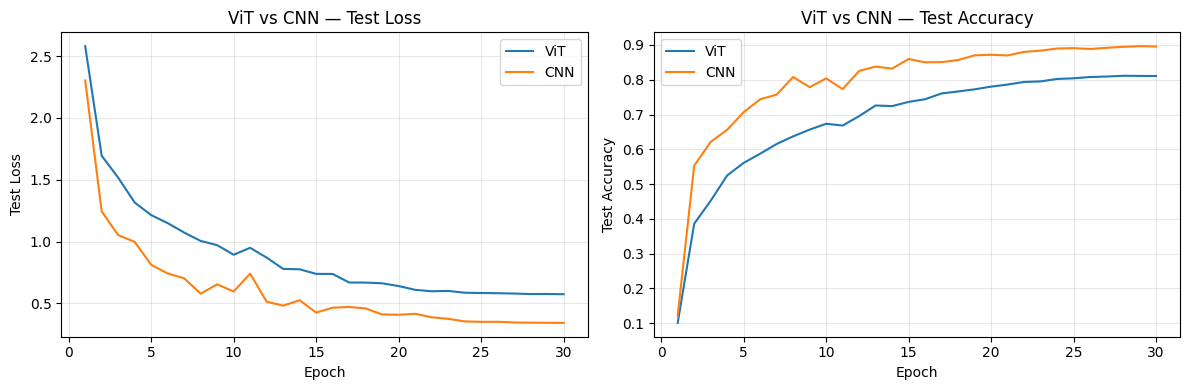

ViT best test acc: 0.811 (4,771,082 params)
CNN best test acc: 0.897 (1,149,770 params)
Avg time/epoch — ViT: 48.0s, CNN: 20.2s


In [78]:
# --- Compare ViT vs CNN ---

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(baseline_metrics['test_accs']) + 1)

axes[0].plot(epochs_range, baseline_metrics['test_losses'], label='ViT')
axes[0].plot(epochs_range, cnn_metrics['test_losses'], label='CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Test Loss')
axes[0].set_title('ViT vs CNN — Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, baseline_metrics['test_accs'], label='ViT')
axes[1].plot(epochs_range, cnn_metrics['test_accs'], label='CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('ViT vs CNN — Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ViT best test acc: {max(baseline_metrics['test_accs']):.3f} ({vit_params:,} params)")
print(f"CNN best test acc: {max(cnn_metrics['test_accs']):.3f} ({cnn_params:,} params)")
print(f"Avg time/epoch — ViT: {sum(baseline_metrics['epoch_times'])/len(baseline_metrics['epoch_times']):.1f}s, "
      f"CNN: {sum(cnn_metrics['epoch_times'])/len(cnn_metrics['epoch_times']):.1f}s")

---
## Section 15 — Summary and Connections

### What you built
- A complete Vision Transformer from scratch: patch embedding, bidirectional multi-head self-attention, Transformer blocks, CLS token classification.
- Attention map visualization to understand what ViT "looks at."
- Three ablations comparing design choices: CLS vs GAP, positional embeddings, ViT vs CNN.

### Key takeaways
1. **Bidirectional attention = encoder attention.** The only difference from your GPT decoder is removing the causal mask. This same attention appears in BERT, ViT, CLIP's image encoder, and every encoder-only model.

2. **Patch tokenization** bridges vision and language. By treating patches as tokens, the same Transformer architecture handles both modalities. This is the foundation of CLIP (Project 6) and all vision-language models.

3. **Inductive bias tradeoff.** CNNs bake in locality and translation equivariance; ViTs learn everything from data. On small datasets CNNs win; on large datasets ViTs win. Understanding this tradeoff is essential for choosing architectures in production.

4. **Positional embeddings are critical** because self-attention is permutation-equivariant by default. Without position information, the model cannot distinguish spatial arrangements.

### What comes next

**Project 5 (ReAct Agent)** — You'll use autoregressive generation from GPT in a structured reasoning loop with tool calls. Different from this project's encoder-style model, but builds on the same generation mechanics.

**Project 6 (CLIP)** — You'll combine this ViT (as the image encoder) with a Transformer text encoder, training them jointly with contrastive loss. The ViT you built here is essentially one half of CLIP.